In [7]:
#session 2 - 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.datasets import load_iris

In [8]:
data = load_iris()
data
df= pd.DataFrame(data.data,columns = data.feature_names)
df
df["Target"]=data.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [15]:
X,y = load_iris(return_X_y=True)
print(X.shape,y.shape)
print(X[(0,1)])

(150, 4) (150,)
3.5


In [12]:
# Rename columns : df.columns=[...]
df.columns=['SL','SW','PL','PW','Target']
df

,SL,SW,PL,PW,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [21]:
#sea the columns name
df.columns
#show as a list
df.columns.tolist()
#number of the columns and rows:
df.shape[0]
df.shape[1]

150

In [6]:
#describe for one column:
df['SL'].describe()
#df['SL'].max()

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: SL, dtype: float64

In [27]:
#Computar science part
#Type and datatype :
type(df)
#data type each columns:
df.dtypes
# Finde the momory it takes:
df.memory_usage()
#Why 1200:
a=df.iloc[0,0]
#a.itemsize # =8 : each cell is 8 byte
# Wrong:a.dtaypes
type(a) # 64 : so 64 = 8 byte ---> 64 bite/8 = 8 byte
#150 * 8 = 1200 byte
#df.memory_usage()
#for Target is 600 why: int32/8 = 4byte *150 = 600

numpy.float64

In [28]:
#Example showing difference between 64,32 e.x
a=np.float64(3.4343536467)
b=np.float32(3.4343536467)
#a = 3.4343536467
b
#a showing more decimal
#a.itemsize
b.itemsize

4

In [9]:
# Problem : change the dtype for save memory
df['SL'].astype(np.float32)
#all 
df2 = df.astype({
    'SL': 'float32',
    'SW': 'float32',
    'PL': 'float32'
})
df2.dtypes

#df.dtypes= WRONG diesn't need '='

SL        float32
SW        float32
PL        float32
PW        float64
Target      int32
dtype: object

In [37]:
q = [{"a":[1,2,3,4],'h':8}]
dfe = pd.DataFrame(q)
dfe.shape
dfe

,a,h
0,"[1, 2, 3, 4]",8


In [50]:
#series and dataframe
type(df.loc[4]) #series
df.loc[4]
df.loc[[4]] #dataframe
df.loc[4:8] #dataframe
df.iloc[4,2]
df.loc[4:8, 'SW'] #series
df.loc[4:8,['SW']] #dataframe
df.loc[4:8,:'SW'] #dataframe

,SL,SW
4,5.0,3.6
5,5.4,3.9
6,4.6,3.4
7,5.0,3.4
8,4.4,2.9


In [53]:
#uniqe values count:
df['Target'].value_counts()
df['SL'].value_counts() #here is not practical
df.Target.unique()

array([0, 1, 2])

In [12]:
# Plots with matplotlib and seaborn

<Axes: xlabel='ax'>

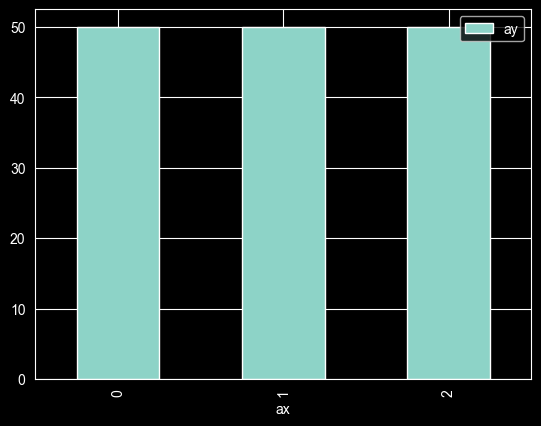

In [70]:
#plt: plt.type(x,y) vs sns
# Bar
a=df['Target'].value_counts()
a
#plt.figure(figsize=(4,4))
#plt.bar(a.index,a.values,color=['red','green','yellow'],edgecolor='black')
#plt.show() #delete title
#plt.xlabel('Species')
#plt.ylabel('Count')
#plt.figure(figsize=(6,4))
#plt.show()
#sns.barplot(df,x=a.index,y=a.values)
#plt.xlabel('Species')
#plt.ylabel('Count')
#plt.show()

#plt.figure()
ax=a.index
ay=a.values
#df.plot(kind='bar',x='ax',y='ay') #error
df2=pd.DataFrame({
    'ax':a.index,
'ay':a.values
})
df2.plot.bar(x='ax',y='ay')

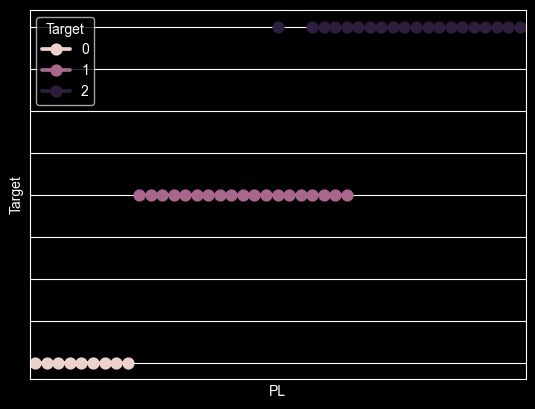

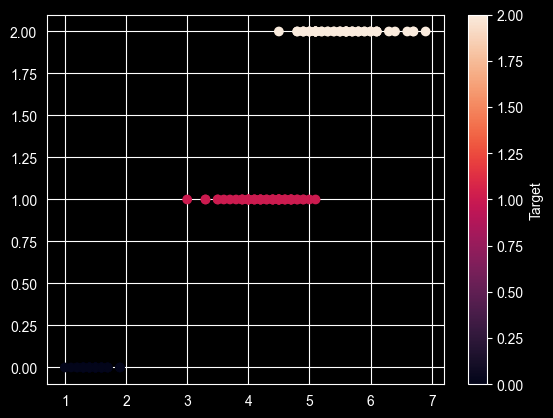

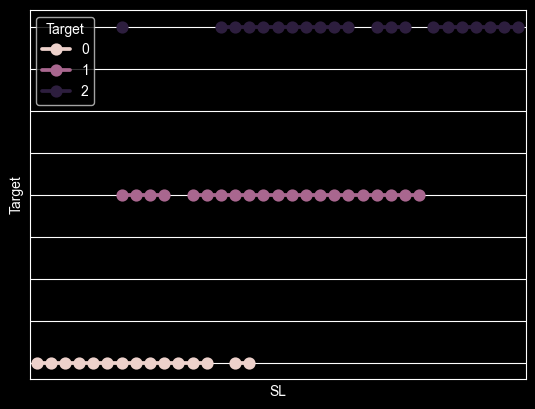

In [73]:
#Scatter, point
plt.figure()
ax=sns.pointplot(data=df,x='PL',y='Target', hue='Target')
ax.tick_params(axis='x',labelbottom=False)
ax.tick_params(axis='y',labelleft=False)
# same with plt
plt.figure()
sc=plt.scatter(df['PL'], df['Target'],c= df['Target'])
plt.colorbar(sc,label='Target')
plt.figure()
ax=sns.pointplot(data=df,x='SL',y='Target', hue='Target')
ax.tick_params(axis='x',labelbottom=False)
ax.tick_params(axis='y',labelleft=False)

array([1.        , 1.53636364, 2.07272727, 2.60909091, 3.14545455,
       3.68181818, 4.21818182, 4.75454545, 5.29090909, 5.82727273,
       6.36363636, 6.9       ])

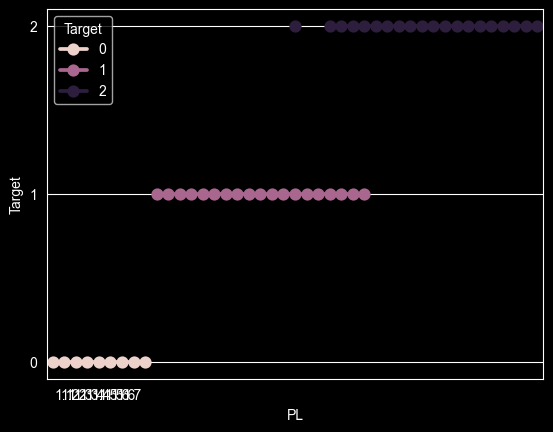

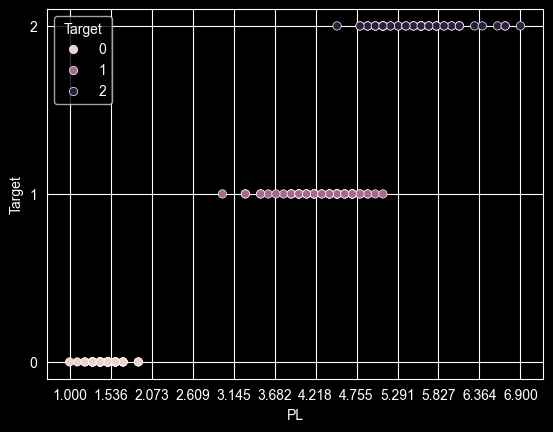

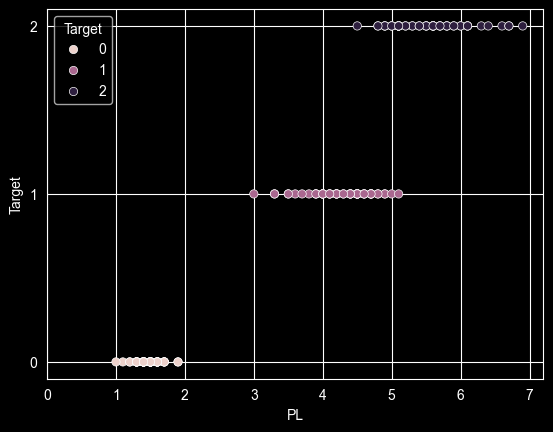

In [80]:
# Problem 1:
plt.figure()
ax=sns.pointplot(data=df,x='PL',y='Target', hue='Target')
axis =np.linspace(df['PL'].min(),df['PL'].max(),12)
axis
ax.set_xticks(axis)
ax.set_yticks([0,1,2])
# X doesn't work right because it takes categorial 
plt.figure()
ax=sns.scatterplot(data=df,x='PL',y='Target', hue='Target')
axis =np.linspace(df['PL'].min(),df['PL'].max(),12)
axis
ax.set_xticks(axis)
ax.set_yticks([0,1,2])

plt.figure()
ax=sns.scatterplot(data=df,x='PL',y='Target', hue='Target')
#axis =np.linspace(df['PL'].min(),df['PL'].max(),5)
#axis
ax.set_xticks([0,1,2,3,4,5,6,7])
ax.set_yticks([0,1,2])
axis

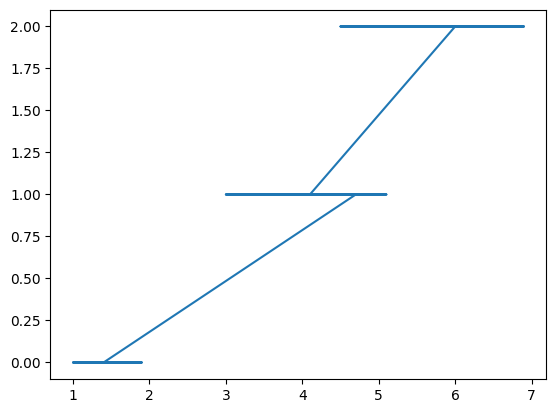

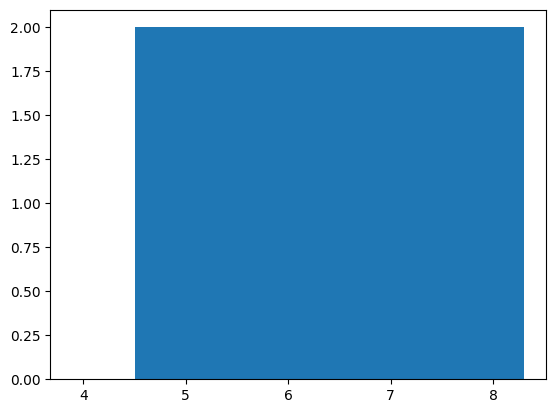

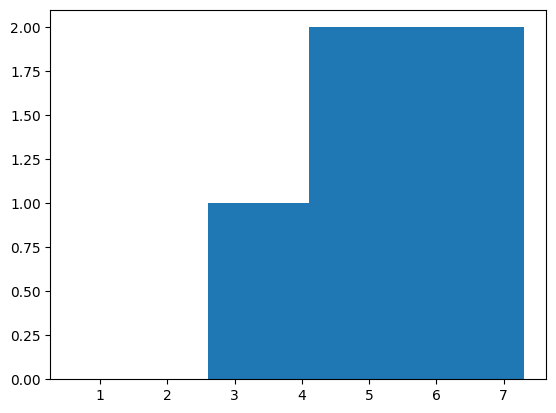

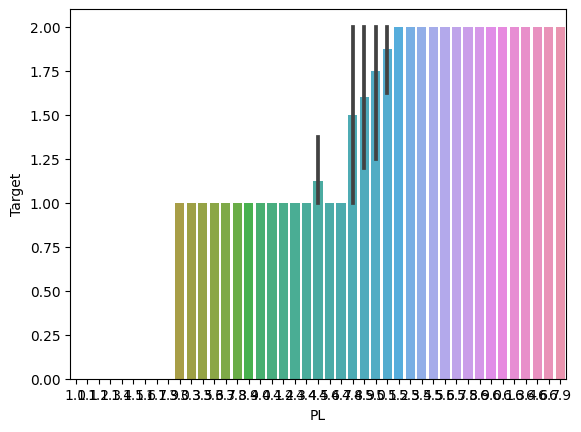

In [16]:
#Random plots:
plt.figure()
plt.plot(df["PL"],df["Target"])
plt.figure()
plt.bar(df["SL"], df["Target"]) #it shoow SL is not a good feature for prediction
plt.figure()
plt.bar(df["PL"],df['Target'],label='PL')

plt.figure()
axx=sns.barplot(df,x='PL',y='Target')

RangeIndex(start=0, stop=150, step=1)

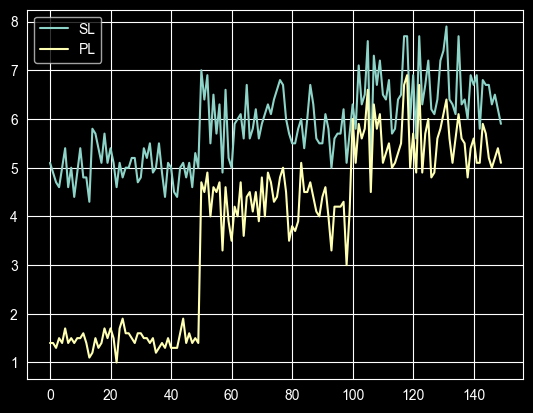

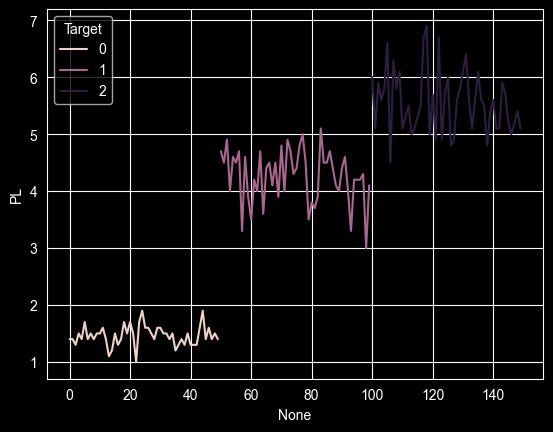

In [81]:
#Plt for finding best feature for prediction
# Scatter was one way
#another plot:
plt.figure()
df.index
plt.plot(df.index,df['SL'],label='SL')
plt.plot(df.index, df['PL'], label='PL')
#show two plots in same page with legend()
plt.legend()

plt.figure()
sns.lineplot(data=df, x=df.index, y='PL',hue='Target')
df.index

<Figure size 640x480 with 0 Axes>

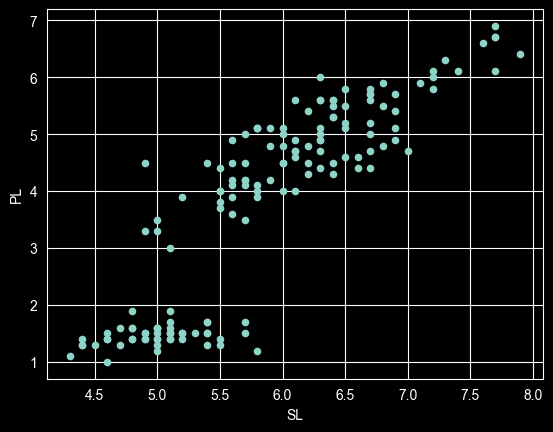

<Figure size 640x480 with 0 Axes>

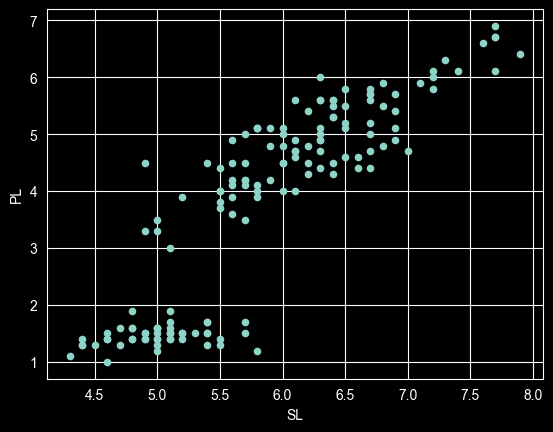

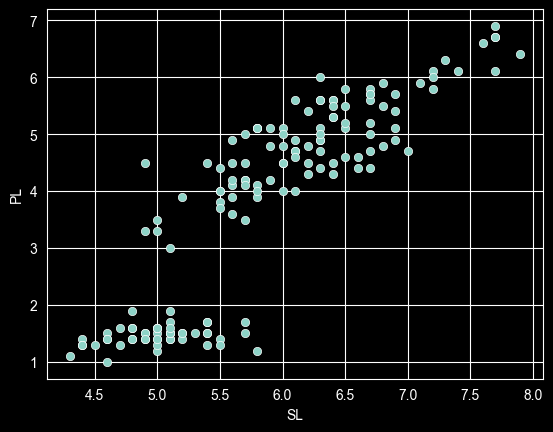

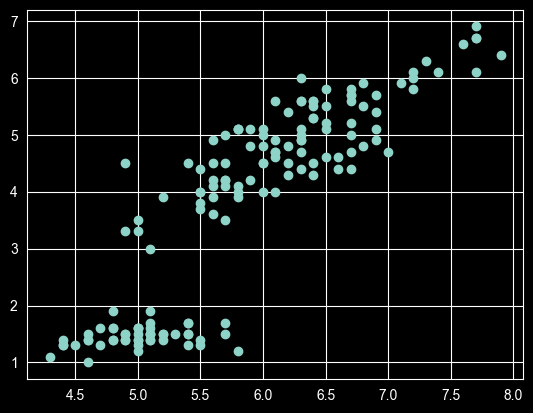

In [82]:
#Several ways to show same plot
plt.figure()
df.plot.scatter(x='SL', y='PL')

plt.figure()
df.plot(kind='scatter', x='SL', y='PL')

plt.figure()
sns.scatterplot(df, x='SL', y='PL')

plt.figure()
plt.scatter(df['SL'], df['PL'])

C:\Users\top\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='PL', ylabel='Count'>

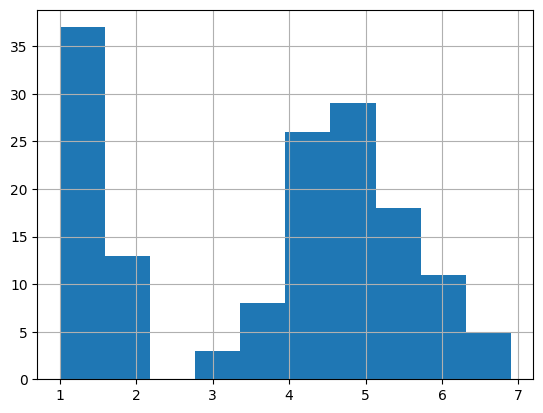

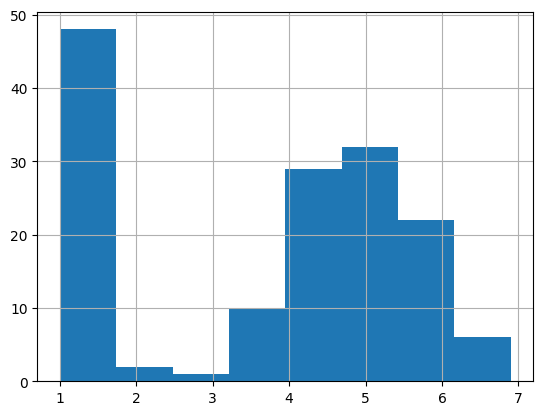

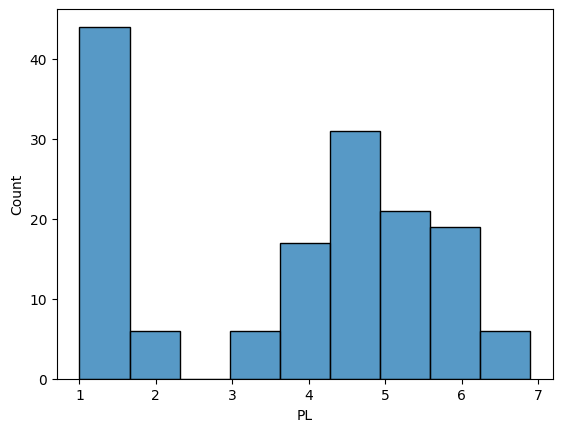

In [19]:
#Histogram:
plt.figure()
plt.hist(df['PL'])
plt.grid()

plt.figure()
df['PL'].hist(bins=8)
#or df.hist(['PL'])

plt.figure()
sns.histplot(df,x='PL')

#bins bydifult is 10
#you can change 

(array([5., 3., 7., 4.]),
 array([ 0., 20., 40., 60., 80.]),
 <BarContainer object of 4 artists>)

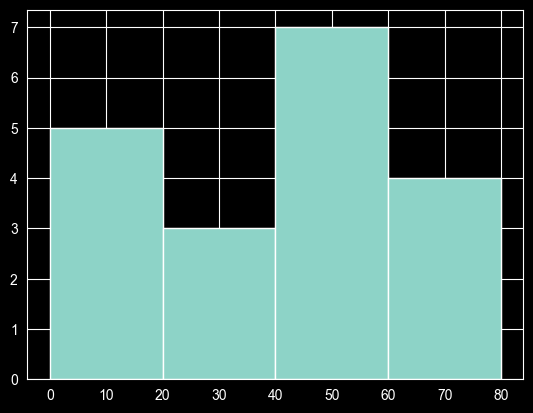

In [91]:
#pd.cut(df['PL'], bins=5)
# 1) ساخت یک دیتافریم نمونه
df4 = pd.DataFrame({
    'age': [5, 17, 25, 33, 48, 52, 67, 75,5,44,73,5,5,25,42,42,42,42,61,91]
})

# 2) تعریف بازه‌ها (bins) و برچسب‌ها (labels)
bins = [0, 20, 40, 60, 80]
labels = ['young', 'adult', 'middle', 'senior']

# 3) تقسیم داده‌ها به بازه‌ها با pd.cut (بدون هیچ نموداری)
df4['age_group'] = pd.cut(df4['age'], bins=bins, labels=labels)
df4
# 4) نمایش نتیجه
#print(df)
#pd.cut(df4['age'], bins=4) # 4 parts equally
#bins = [0,20,40,60,80]
#labels=['A','B','C','D']
#df4['age_group']=pd.cut(df4['age'],bins=bins,labels=labels)
#df4
# range = 0-20  20-40  40-60  60-80
plt.hist(df4['age'],bins=bins)

In [21]:
pd.cut(df['PL'],bins=10)

0      (0.994, 1.59]
1      (0.994, 1.59]
2      (0.994, 1.59]
3      (0.994, 1.59]
4      (0.994, 1.59]
           ...      
145     (5.13, 5.72]
146     (4.54, 5.13]
147     (5.13, 5.72]
148     (5.13, 5.72]
149     (4.54, 5.13]
Name: PL, Length: 150, dtype: category
Categories (10, interval[float64, right]): [(0.994, 1.59] < (1.59, 2.18] < (2.18, 2.77] < (2.77, 3.36] ... (4.54, 5.13] < (5.13, 5.72] < (5.72, 6.31] < (6.31, 6.9]]

In [22]:
df['PL'].describe()

count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: PL, dtype: float64

<Axes: >

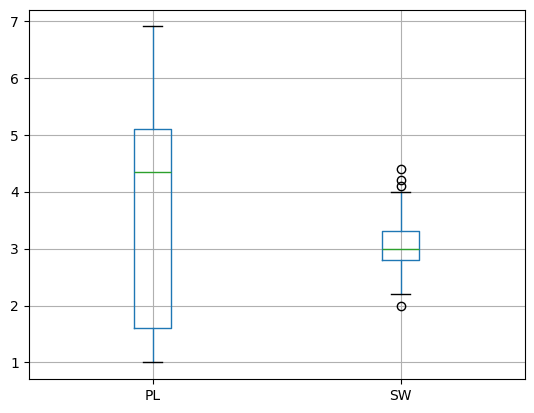

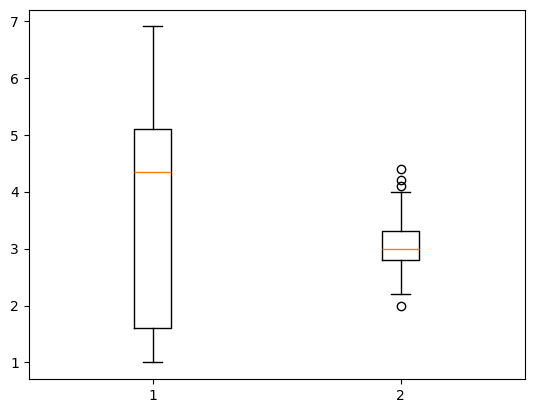

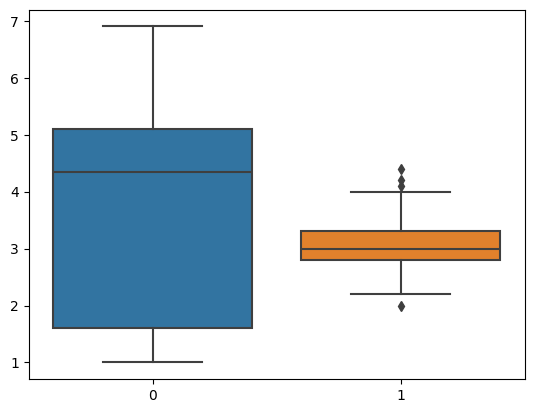

In [23]:
#Box plot:
#df.hist(['PL'])
plt.figure()
df.boxplot(['PL',"SW"])
# Wrong way : df['PL'].boxplot() 

plt.figure()
plt.boxplot([df['PL'],df['SW']])

plt.figure()
#sns.boxplot(df[['PL','SW']])
sns.boxplot([df['PL'],df['SW']])

C:\Users\top\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\top\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\top\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\top\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead

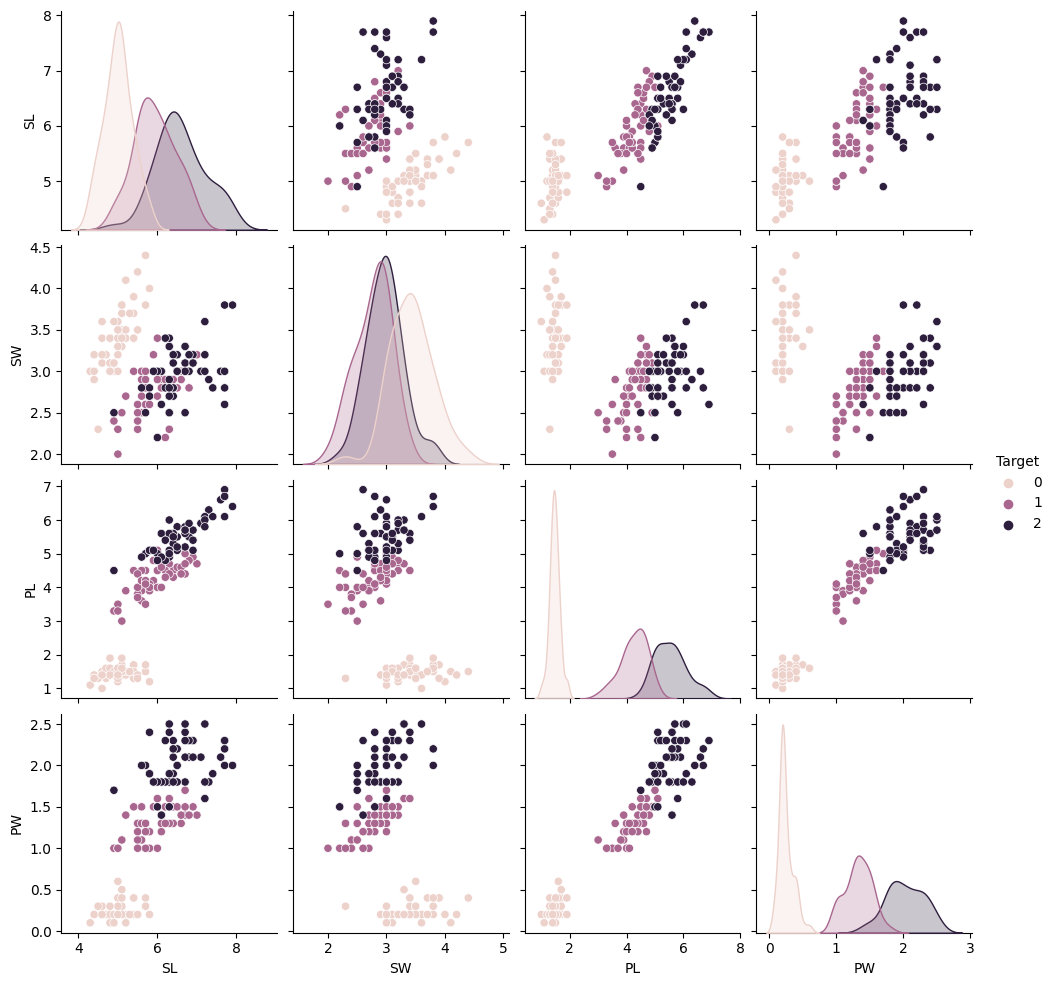

In [24]:
#all 
sns.pairplot(df,hue='Target')